# Diffusion for Image Generation

## Some Reference
- Diffusion course from Huggingface: https://huggingface.co/learn/diffusion-course/en/unit1/3
- Kian Ming A. Chai (Data61)'s Variational Learning of Fractional Posteriors (unpublished)

## Setup
### Key parameters
- Apparently, batch size is an *important hyperparameter* in learning such models: https://x.com/Yampeleg/status/1674034884652802048

In [1]:
### Data
batch_size = 128 # Used by torch.utils.data.DataLoader for mini-batching for training

### Model parameters
theoryclass = "diff"                    # Diffusion with multiple objectives (diffmulti)
priorparams = 1e-10

### Training parameters
num_epochs = 10             # number of training epochs **commandline configurable**
retrain = True              # **commandline configurable**
learning_rate = 1e-3        # input to Adam optimiser  ##8,5 works

### These are not so key
WRsamples = 200      # for geneating "Exact" posterior samples 
gpudevice = "cuda:1"   # **commandline configurable**

### System
- to run from command line, convert this notebook with jupyter nbconvert filename.ipynb --to python
- to run from Google colab, download and copy to your drive

In [2]:
### Check Colab
import sys,os

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir('/content/drive/MyDrive/')
    dgm_dir = '/content/drive/MyDrive/vlfp/'
    if not os.path.exists(dgm_dir):
        raise Exception("Code does not exists. Download and copy to your drive under the directory vlfp")
    else:
        print("Code already exists")
    sys.path.append(os.path.dirname(dgm_dir)) # Allow our own modules
    os.chdir('/content/drive/MyDrive/vlfp/notebooks/')

    # sensible settings within (free) collab to override key_parameters
    is_interactive = lambda: True
    batch_size = 2048 if batch_size > 2048 else batch_size
    num_epochs = 20 if num_epochs > 20 else num_epochs
    gpudevice = "cuda:0"
else:
    import __main__ as main
    sys.path.append(os.path.abspath('..')) # Allow our own modules
    is_interactive = lambda: not hasattr(main, '__file__')

In [3]:
### Perhaps Load the parameters from commandline
if not is_interactive():
    # we have a chance to change the fixed parameters
    print("Using commandline arguments: %s" % (sys.argv));

    from argparse import ArgumentParser
    argparser = ArgumentParser()
    argparser.add_argument("--epochs", type=int)
    argparser.add_argument("--theoryclass", type=str, choices=("diff"))
    argparser.add_argument("--device", type=str)
    argparser.add_argument("--skiptrain", action="store_true")
    args = argparser.parse_args()

    num_epochs = args.epochs
    theoryclass = args.theoryclass
    gpudevice = args.device
    retrain = False if args.skiptrain else True # this would be the default

In [4]:
### Make sure that we can indeed run.
import torch
device = torch.device(gpudevice if torch.cuda.is_available() else "cpu")

### Logging

In [5]:
out_file = ("./results/%s-mnist-n-b-%d") % (theoryclass, batch_size)
print("Device=%s\nFile=%s" % (device, out_file))

Device=cuda:1
File=./results/diff-mnist-n-b-128


## Prepare Image Data

https://pytorch.org/vision/stable/transforms.html#supported-input-types-and-conventions
- Tensor image are expected to be of shape (C, H, W), where C is the number of channels, and H and W refer to height and width. Most transforms support batched tensor input. A batch of Tensor images is a tensor of shape (N, C, H, W), where N is a number of images in the batch. The v2 transforms generally accept an arbitrary number of leading dimensions (..., C, H, W) and can handle batched images or batched videos.

For data sets, see https://pytorch.org/vision/stable/datasets.html

In [6]:
### Nice plotting
import matplotlib.pyplot as plt

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data/MNIST
    Split: Train
    StandardTransform
Transform: ToTensor()


/apps/python/3.12.0/lib/python3.12/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/apps/python/3.12.0/lib/python3.12/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


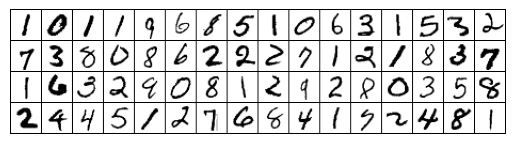

In [7]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
import utils.dataAugment as dataAugment

img_transform = torchvision.transforms.ToTensor()

train_dataset = MNIST(root='./data/MNIST', download=True, train=True, transform=img_transform)

print(train_dataset)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
x, _ = next(iter(train_dataloader))
x = x[0:64,:,:,:]

fig = plt.Figure()
if hasattr(fig, "show"):
    plt.imshow(torchvision.utils.make_grid(x, 16, padding=1, pad_value=1.0)[0], vmin=0, vmax=1, cmap='Greys');
    plt.axis("off")
    plt.margins(0, 0)
    plt.show()

## The Corruption Process

In [8]:
from torch.distributions.continuous_bernoulli import ContinuousBernoulli as Likelihood
from inf.diffdist import ApproximatePosterior, ExactPosterior

Posterior = ExactPosterior
#Posterior = ApproximatePosterior

In [9]:
def justprior(shape, prior):
  """ Just generate from prior.
      We could have just used the corrupt function below with amount=0,
      but this is to prevent any doubt or accidental information leakage. """
  if not torch.is_tensor(prior):
      prior = torch.tensor(prior).float().to(x.device)
  prior = prior.expand(shape)
  post = Posterior(prior, prior, 0, WRsamples)
  p = post.sample()
  noisy_x = Likelihood(probs = p).sample()
  return noisy_x, p
    
def corrupt(x, amount, prior):
  """Corrupt the input `x` by mixing it with noise according to `amount`"""
  if not torch.is_tensor(amount):
      amount = torch.tensor(amount).float().to(x.device)
  amount = amount.view(-1, 1, 1, 1) # Sort shape so broadcasting works
  post = Posterior(prior + amount * x, prior + amount * (1.0-x), amount,  WRsamples)
  p = post.sample()
  noisy_x = Likelihood(probs = p).sample()

  return noisy_x, p, post

We calibrate the data so that the range of noisy samples looks "Okay", and so that the initial MSEloss of the training loop matches that of the tutorial (around 0.025), which uses Gaussian-like models.

/apps/pytorch/2.1.1-py312-cu122-mpi/lib/python3.12/site-packages/torch/distributions/distribution.py:53: UserWarning: <class 'inf.diffdist.ExactPosterior'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(


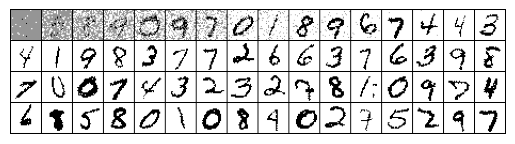

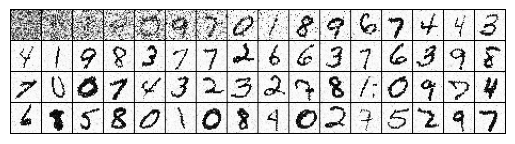

In [10]:
from torch.distributions.beta import Beta as SampleDataAmount

x, _ = next(iter(train_dataloader))
x = x[0:64,:,:,:]

amount_dist = SampleDataAmount(0.4, 4)
amount = amount_dist.sample([x.shape[0]]).to(x.device) # Pick random noise amounts
amount, _ = torch.sort(amount)
noised_x, lbda, _ = corrupt(x, amount,  priorparams)
plt.imshow(torchvision.utils.make_grid(lbda.cpu(), 16, padding=1, pad_value=1.0)[0], vmin=0, vmax=1, cmap='Greys');
plt.axis("off")
plt.margins(0, 0)
plt.show()
plt.imshow(torchvision.utils.make_grid(noised_x.cpu(), 16, padding=1, pad_value=1.0)[0], vmin=0, vmax=1, cmap='Greys');
plt.axis("off")
plt.margins(0, 0)
plt.show()

## The Model

We use the BasicUNet from the tutorial, but modify it so that we can change the final activiation function

In [11]:
from nnarch.diffnn import BasicUNetSetOut
net = BasicUNetSetOut()

x = torch.rand(8, 1, 28, 28)
print("Check shape: ", net(x).shape)
print("Number of parameters: ", sum([p.numel() for p in net.parameters()]))

Check shape:  torch.Size([8, 1, 28, 28])
Number of parameters:  309057


## Training the network

Finished epoch 0. Average loss for this epoch: 0.026149
Finished epoch 1. Average loss for this epoch: 0.021633
Finished epoch 2. Average loss for this epoch: 0.020488
Finished epoch 3. Average loss for this epoch: 0.019885
Finished epoch 4. Average loss for this epoch: 0.019555
Switching to Sigmoid
Finished epoch 5. Average loss for this epoch: 0.022017
Finished epoch 6. Average loss for this epoch: 0.019345
Finished epoch 7. Average loss for this epoch: 0.018887
Finished epoch 8. Average loss for this epoch: 0.018550
Finished epoch 9. Average loss for this epoch: 0.018604


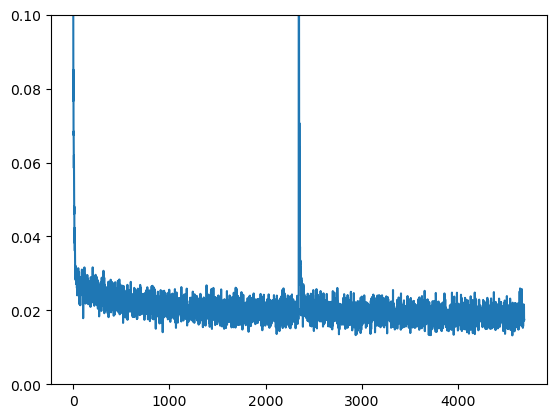

In [12]:
import math
from torch import nn

net.to(device)

# Our loss function
# It doesn't matter much what our loss function is, as long as the end point is the same
# This this loss seems to interact better with the network
loss_fn = nn.MSELoss()

# The optimizer
opt = torch.optim.Adam(net.parameters(), lr=learning_rate)

# Keeping a record of the losses for later viewing
losses = []

# The training loop
for epoch in range(num_epochs):
    if epoch == math.floor(num_epochs/2):
        net.setout(nn.Sigmoid())
        print("Switching to Sigmoid")
    
    for x, _ in train_dataloader:

        # Get some data and prepare the corrupted version
        x = x.to(device) # Data on the GPU

        noise_amount = amount_dist.sample([x.shape[0]]).to(x.device) # Pick random noise amounts
        noisy_x, *_ = corrupt(x, noise_amount,  priorparams) # Create our noisy x
        
        # Get the model prediction
        pred = net(noisy_x)

        # Calculate the loss
        loss = loss_fn(pred, x) # How close is the output to the true 'clean' x?

        # Backprop and update the params:
        opt.zero_grad()
        loss.backward()
        opt.step()

        # Store the loss for later
        losses.append(loss.item())

    # Print our the average of the loss values for this epoch:
    avg_loss = sum(losses[-len(train_dataloader):])/len(train_dataloader)
    print(f'Finished epoch {epoch}. Average loss for this epoch: {avg_loss:05f}')

# View the loss curve
plt.plot(losses)
plt.ylim(0, 0.1);


We can try to see what the model predictions look like by grabbing a batch of data, corrupting it by different amounts and then seeing the models predictions:

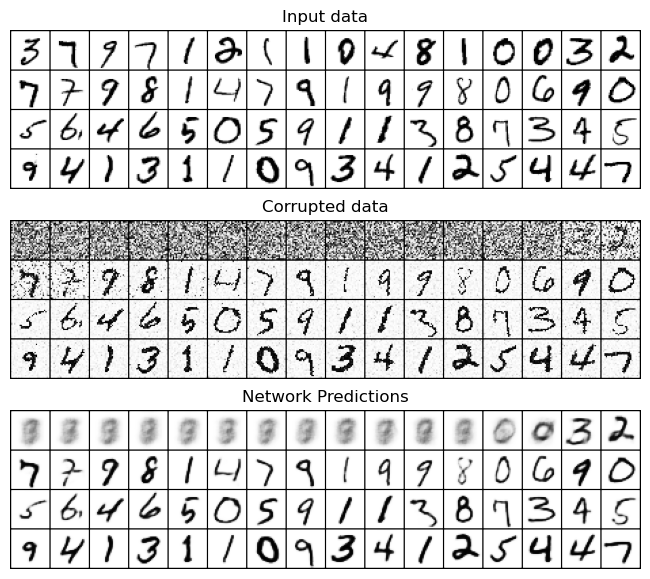

In [13]:
x, _ = next(iter(train_dataloader))
x = x[:64] # Only using the first 64 for easy plotting

# Corrupt with a range of amounts
x = x[0:64,:,:,:]
amount_dist = SampleDataAmount(0.2, 2)
amount = amount_dist.sample([x.shape[0]]).to(x.device) # Pick random noise amounts
amount = torch.sort(amount)[0]
noised_x, *_ = corrupt(x, amount, priorparams)

# Get the model predictions
with torch.no_grad():
  preds = net(noised_x.to(device)).detach().cpu()

# Plot
fig, axs = plt.subplots(3, 1, figsize=(12, 7))
axs[0].set_title('Input data')
axs[0].imshow(torchvision.utils.make_grid(x, 16, padding=1, pad_value=1.0)[0], vmin=0, vmax=1, cmap='Greys');
axs[0].axis("off")
axs[0].margins(0, 0)

axs[1].set_title('Corrupted data')
axs[1].imshow(torchvision.utils.make_grid(noised_x, 16, padding=1, pad_value=1.0)[0], vmin=0, vmax=1, cmap='Greys');
axs[1].axis("off")
axs[1].margins(0, 0)

axs[2].set_title('Network Predictions')
axs[2].imshow(torchvision.utils.make_grid(preds, 16, padding=1, pad_value=1.0)[0], cmap='Greys');
axs[2].axis("off")
axs[2].margins(0, 0)

## Sampling

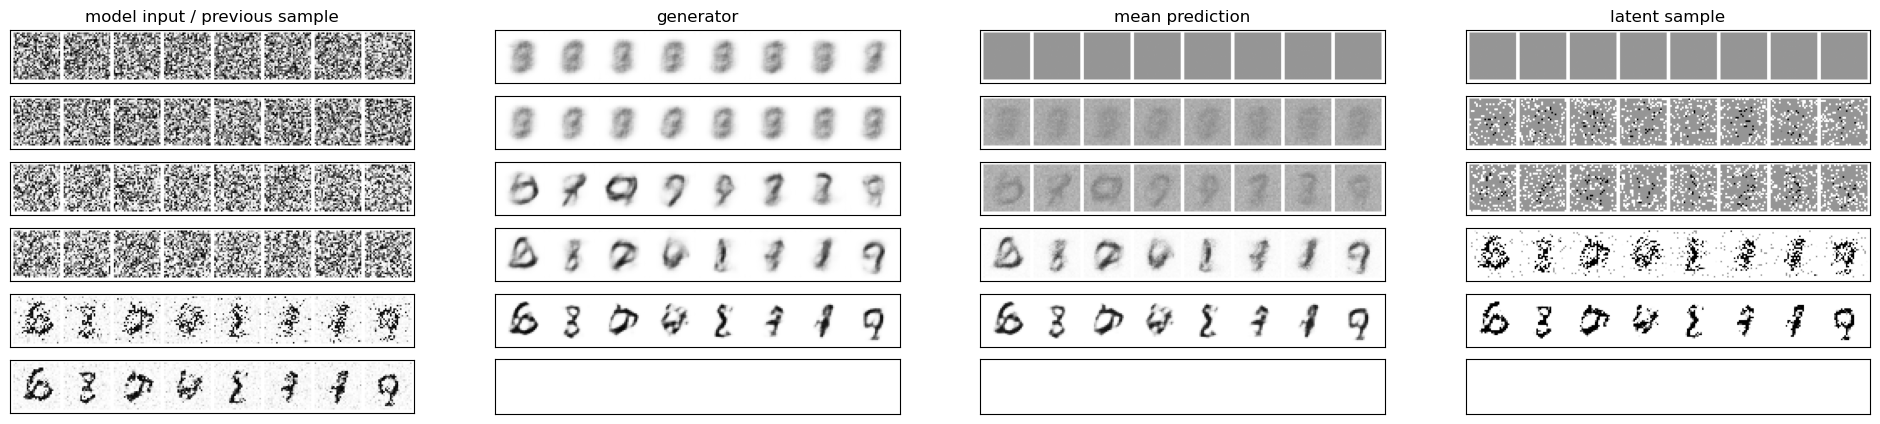

In [14]:
from inf.diffdist import mean_prediction

n_steps = 5
amount = torch.sort(amount_dist.sample([n_steps-1]))[0].tolist() + [1.0]

x, _ = justprior((8,1,28,28), priorparams)
x = x.to(device)
input_history = [x.cpu()]
nn_output_history = []
mean_output_history = []
latent_output_history = []


for i in range(n_steps):
    with torch.no_grad(): # No need to track gradients during inference
        better_x = net(x) # Predict the denoised x0
    noisy_x, lbda, post = corrupt(better_x, amount[i], priorparams)
    mean_x = mean_prediction(post, 100)
        
    nn_output_history.append(better_x.detach().cpu()) # Store model output for plotting
    mean_output_history.append(mean_x.detach().cpu()) # Store model output for plotting    
    latent_output_history.append(lbda.detach().cpu()) # Store model output for plotting    
    x = noisy_x 
    input_history.append(x.detach().cpu()) # Store step for plotting

fig, axs = plt.subplots(n_steps+1, 4, sharex=True, figsize=(24, 1*n_steps))
axs[0,0].set_title('model input / previous sample')
axs[0,1].set_title('generator')
axs[0,2].set_title('mean prediction')
axs[0,3].set_title('latent sample')
for i in range(n_steps+1):
    for j in range(0,4):
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
    axs[i, 0].imshow(torchvision.utils.make_grid(input_history[i])[0], vmin=0, vmax=1, cmap='Greys')
    if i < n_steps:
        axs[i, 1].imshow(torchvision.utils.make_grid(nn_output_history[i])[0], vmin=0, vmax=1, cmap='Greys')
        axs[i, 2].imshow(torchvision.utils.make_grid(mean_output_history[i])[0], vmin=0, vmax=1, cmap='Greys')
        axs[i, 3].imshow(torchvision.utils.make_grid(latent_output_history[i])[0], vmin=0, vmax=1, cmap='Greys')

/tmp/ipykernel_5725/2936348802.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_5725/2936348802.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


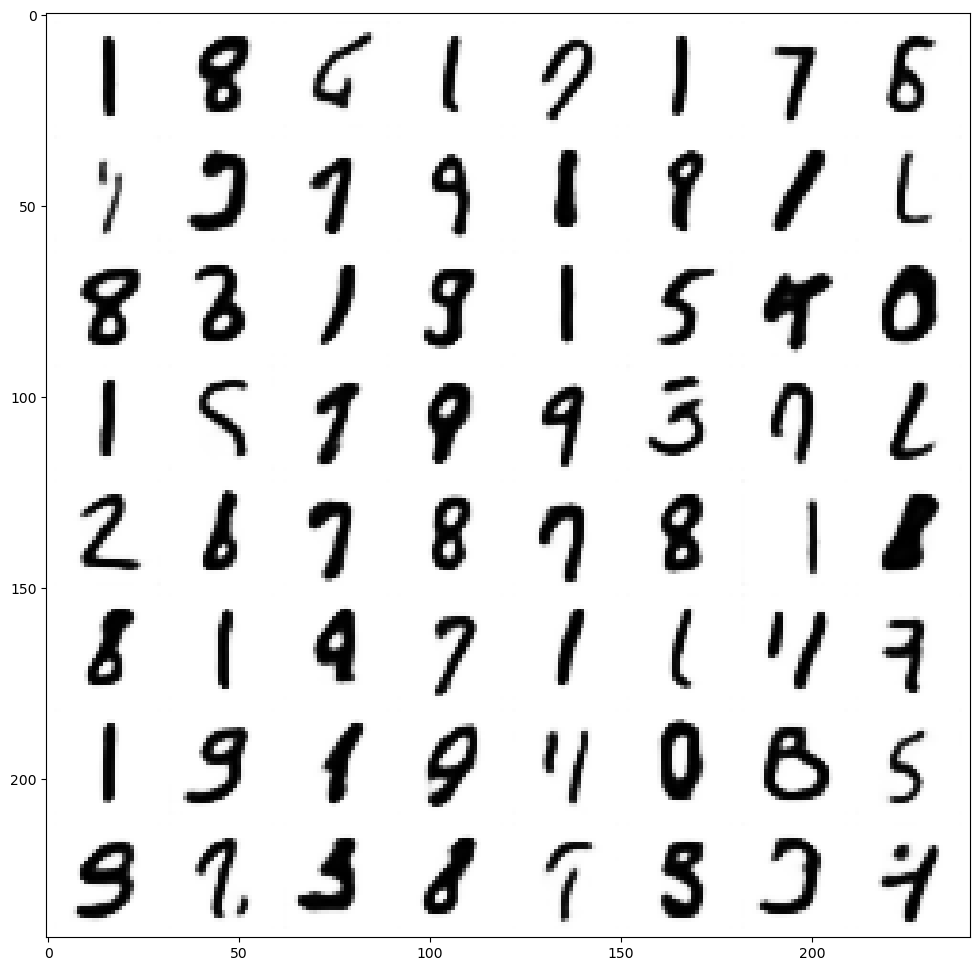

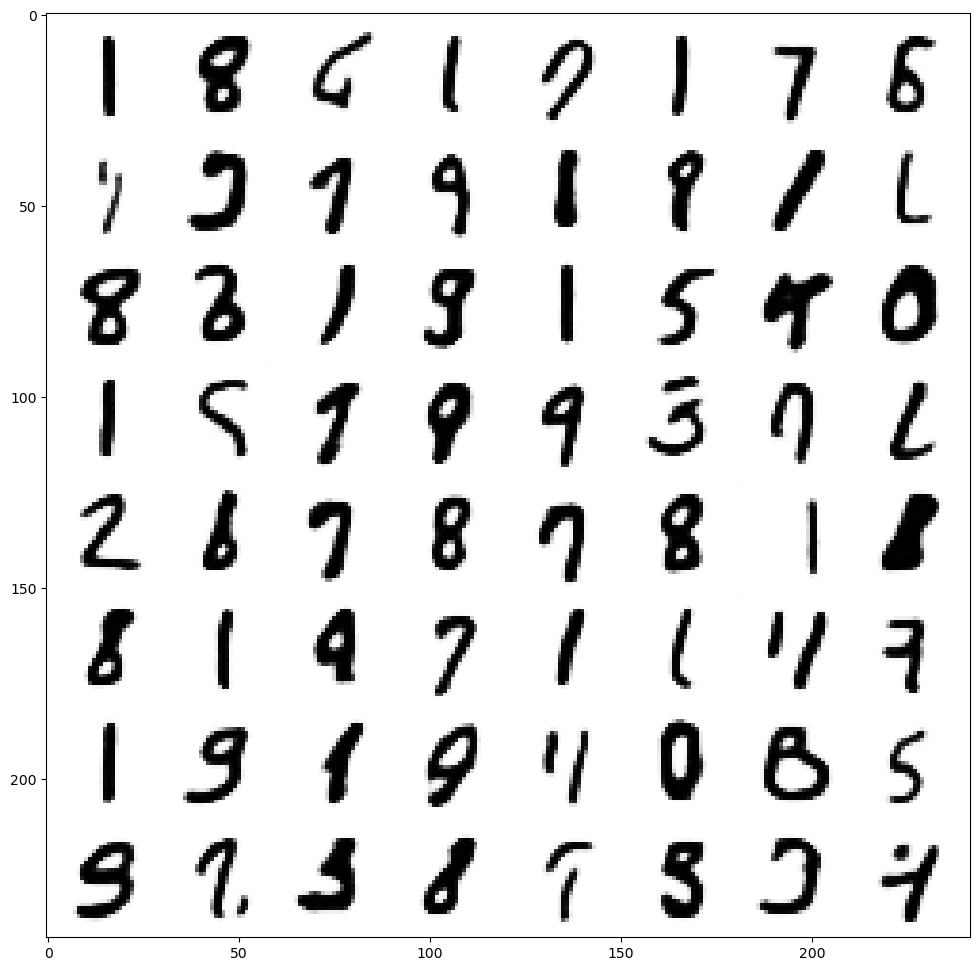

In [15]:
n_steps = 40
amount = torch.sort(amount_dist.sample([n_steps-1]))[0].tolist() + [1.0]

x, _ = justprior((64,1,28,28), priorparams)
x = x.to(device)

for i in range(n_steps):
    with torch.no_grad():
        better_x = net(x)
    x, _, post = corrupt(better_x, amount[i], priorparams)
      
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
ax.imshow(torchvision.utils.make_grid(better_x.detach().cpu(), nrow=8)[0], cmap='Greys')
fig.show()

mean_x = mean_prediction(post, 100)
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
ax.imshow(torchvision.utils.make_grid(mean_x.detach().cpu(), nrow=8)[0], cmap='Greys')
fig.show()